## Implemention of Ensemble Techniques 

## Scenario 1: Bagging Classifier - Diabetes Prediction

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

In [20]:
df = pd.read_csv('diabetes_bagging.csv')

In [21]:
df.head()

,Glucose,BMI,Age,BloodPressure,Insulin,Outcome
0,182,21.1,45,99,100,1
1,131,35.6,67,92,199,1
2,172,19.6,68,68,234,1
3,94,39.7,21,102,83,0
4,186,35.0,20,113,61,1


In [2]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)       

<IPython.core.display.Javascript object>

In [6]:
# Decision Tree
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

In [7]:
# Bagging
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10)
bag.fit(X_train, y_train)
y_pred_bag = bag.predict(X_test)


In [8]:
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Bagging Accuracy:", accuracy_score(y_test, y_pred_bag))

Decision Tree Accuracy: 1.0
Bagging Accuracy: 1.0


### Accuracy Bar Graph

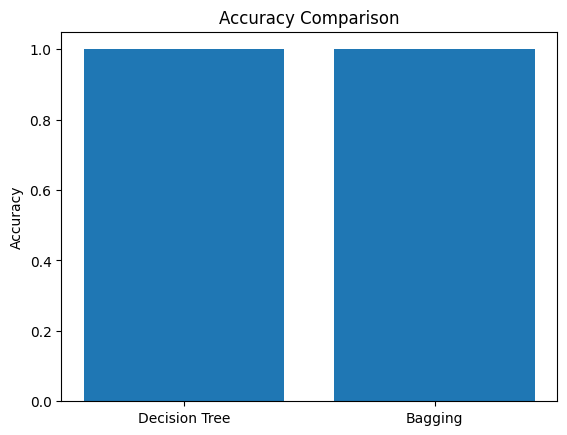

In [9]:
models = ["Decision Tree", "Bagging"]
accuracy = [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_bag)
]

plt.bar(models, accuracy)
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

### Confusion Matrices

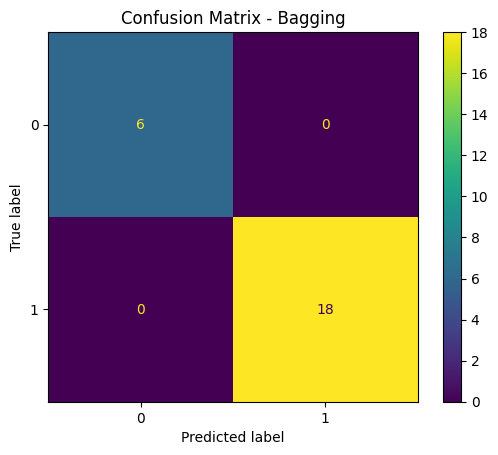

In [14]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bag)
plt.title("Confusion Matrix - Bagging")
plt.show()

## SCENARIO 2 – Boosting (Churn)

In [15]:
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier

In [23]:
df = pd.read_csv("churn_boosting.csv")


In [24]:
df.head()

,Tenure,MonthlyCharges,ContractType,InternetService,Churn
0,65,105.22,Two year,NaN,0
1,17,75.19,Month-to-month,NaN,0
2,71,76.09,Two year,Fiber optic,0
3,45,107.67,Two year,Fiber optic,0
4,4,60.35,Two year,NaN,0


In [25]:
df.isna().sum()

Tenure              0
MonthlyCharges      0
ContractType        0
InternetService    43
Churn               0
dtype: int64

In [27]:
df["InternetService"].fillna(df["InternetService"].mode()[0], inplace=True)

In [41]:
df.head()

,Tenure,MonthlyCharges,ContractType,InternetService,Churn
0,65,105.22,2,0,0
1,17,75.19,0,0,0
2,71,76.09,2,1,0
3,45,107.67,2,1,0
4,4,60.35,2,0,0


In [31]:
le = LabelEncoder()

df["ContractType"] = le.fit_transform(df["ContractType"])
df["InternetService"] = le.fit_transform(df["InternetService"])

<IPython.core.display.Javascript object>

In [42]:
X = df.drop(["Churn","InternetService"], axis=1)
y = df["Churn"]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [49]:
# AdaBoost
ada_model = AdaBoostClassifier(n_estimators=20, random_state=42)
ada_model.fit(X_train, y_train)

c:\Users\freaky manoj\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoostClassifier(n_estimators=20, random_state=42)

In [52]:
y_pred_ada = ada_model.predict(X_test)
ada_acc = accuracy_score(y_test, y_pred_ada)

In [50]:
gb_model = GradientBoostingClassifier(n_estimators=50, random_state=42)
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(n_estimators=50, random_state=42)

In [53]:
y_pred_gb = gb_model.predict(X_test)
gb_acc = accuracy_score(y_test, y_pred_gb)


In [54]:
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

AdaBoost Accuracy: 0.9583333333333334
Gradient Boosting Accuracy: 0.9583333333333334


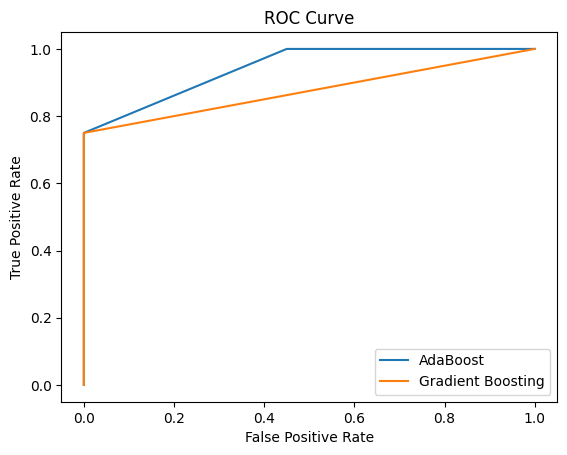

In [55]:
from sklearn.metrics import roc_curve, auc

# Probabilities
y_prob_ada = ada.predict_proba(X_test)[:,1]
y_prob_gb = gb.predict_proba(X_test)[:,1]

fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.plot(fpr_ada, tpr_ada, label="AdaBoost")
plt.plot(fpr_gb, tpr_gb, label="Gradient Boosting")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

<IPython.core.display.Javascript object>

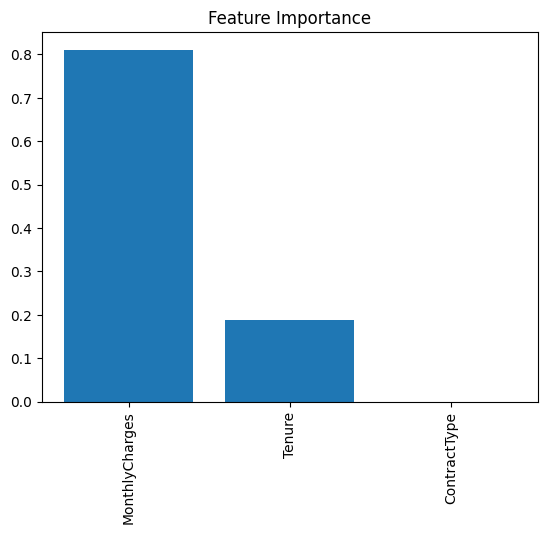

In [56]:
importances = gb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure()
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.title("Feature Importance")
plt.show()

## SCENARIO 3 – Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
df = pd.read_csv("income_random_forest.csv")

In [59]:
df.head()

,Age,EducationYears,HoursPerWeek,Experience,Income
0,37,12,44,12,0
1,46,19,58,33,1
2,53,10,54,24,0
3,46,11,22,6,0
4,36,17,56,3,1


In [60]:
df.isnull().sum()

Age               0
EducationYears    0
HoursPerWeek      0
Experience        0
Income            0
dtype: int64

In [61]:
X = df.drop("Income", axis=1)   
y = df["Income"]

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [63]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [68]:
y_pred = rf_model.predict(X_test)
base_acc = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", base_acc)

Random Forest Accuracy: 1.0


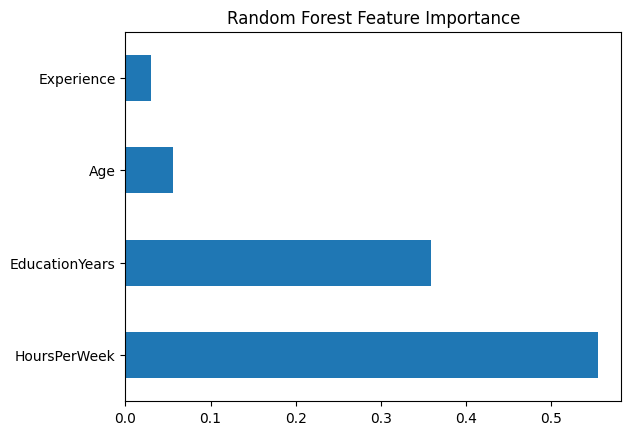

In [67]:
feat_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feat_importance.nlargest(10).plot(kind='barh')

plt.title("Random Forest Feature Importance")
plt.show()

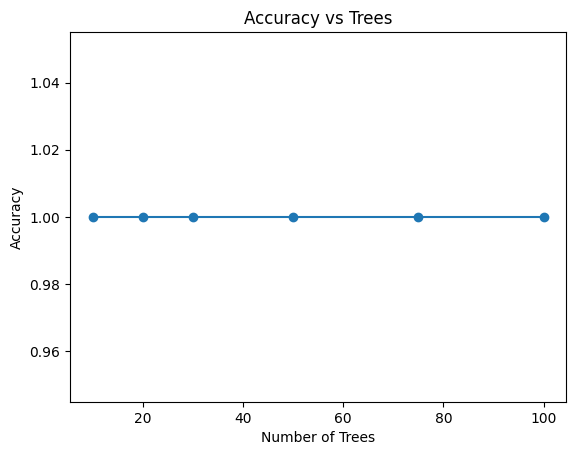

In [65]:
trees = [10, 20,30, 50,75, 100]
acc = []

for n in trees:
    model = RandomForestClassifier(n_estimators=n)
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc.append(accuracy_score(y_test, pred))

plt.plot(trees, acc, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Trees")
plt.show()

## SCENARIO 4 – Stacking

In [69]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

In [70]:
df=pd.read_csv("heart_stacking.csv")

In [71]:
df.head()

,Age,Cholesterol,MaxHeartRate,RestingBP,HeartDisease
0,57,212,189,118,0
1,44,266,155,146,1
2,59,279,168,128,1
3,66,237,123,145,1
4,58,221,125,132,0


In [72]:

X = df[["Cholesterol","MaxHeartRate","Age"]]   # required features
y = df["HeartDisease"]

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [74]:
dt = DecisionTreeClassifier(max_depth=3)
lr = LogisticRegression(max_iter=1000)
svm = SVC(probability=True, C=1.0)

In [75]:
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [76]:
lr_pred = lr.predict(X_test)
svm_pred = svm.predict(X_test)
dt_pred = dt.predict(X_test)

In [77]:
lr_acc = accuracy_score(y_test, lr_pred)
svm_acc = accuracy_score(y_test, svm_pred)
dt_acc = accuracy_score(y_test, dt_pred)

print("Logistic Regression Acc:", lr_acc)
print("SVM Acc:", svm_acc)
print("Decision Tree Acc:", dt_acc)

Logistic Regression Acc: 0.7083333333333334
SVM Acc: 0.7916666666666666
Decision Tree Acc: 0.6666666666666666


In [78]:
estimators = [
    ('lr', LogisticRegression()),
    ('svm', SVC(probability=True)),
    ('dt', DecisionTreeClassifier(max_depth=4))
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression()
)

stack_model.fit(X_train, y_train)

stack_pred = stack_model.predict(X_test)
stack_acc = accuracy_score(y_test, stack_pred)

print("Stacking Accuracy:", stack_acc)

Stacking Accuracy: 0.6666666666666666


### Model Comparison Bar Chart

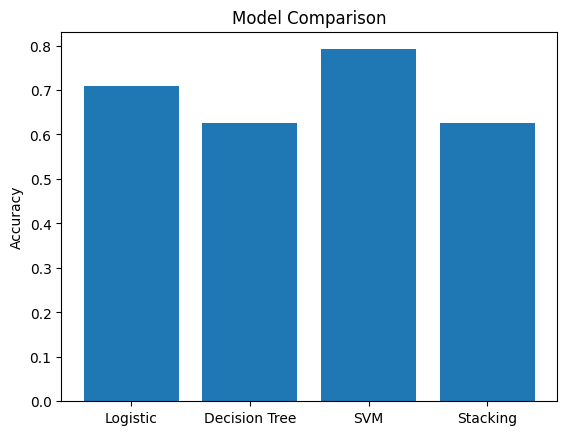

In [79]:
# Individual models
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier()
svm = SVC(probability=True)

models = [lr, dt, svm]
names = ["Logistic", "Decision Tree", "SVM"]
scores = []

for model in models:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    scores.append(accuracy_score(y_test, pred))

# Add stacking
scores.append(accuracy_score(y_test, y_pred))
names.append("Stacking")

plt.bar(names, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

## SCENARIO 5 – SMOTE


In [2]:
from sklearn.metrics import classification_report, precision_recall_curve, auc

In [3]:
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

In [4]:
df = pd.read_csv("fraud_smote.csv")

<IPython.core.display.Javascript object>

In [5]:
df.head()

,Amount,Time,Feature1,Feature2,Fraud
0,3233.38,34595,2.157308,-0.818199,0
1,2783.63,73166,1.561511,0.955305,0
2,923.74,84417,-0.027305,-1.418366,0
3,2214.14,11139,-0.643518,-0.466037,0
4,444.75,37847,0.021272,-0.529053,0


In [6]:
df.isnull().sum()


Amount      0
Time        0
Feature1    0
Feature2    0
Fraud       0
dtype: int64

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

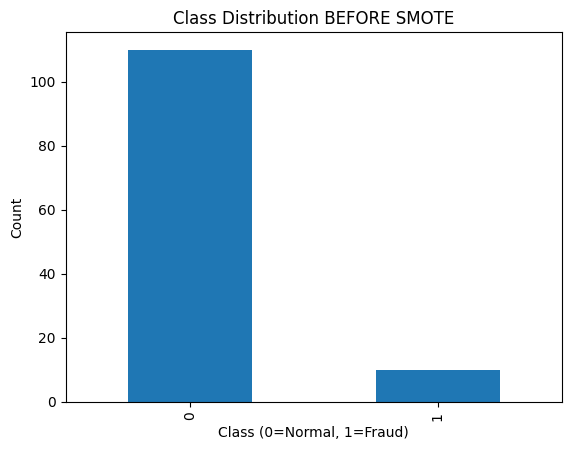

In [7]:
plt.figure()
df["Fraud"].value_counts().plot(kind='bar')
plt.title("Class Distribution BEFORE SMOTE")
plt.xlabel("Class (0=Normal, 1=Fraud)")
plt.ylabel("Count")
plt.show()

In [8]:
X = df.drop("Fraud", axis=1)
y = df["Fraud"]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

<IPython.core.display.Javascript object>

In [10]:

model_before = RandomForestClassifier(n_estimators=100, random_state=42)
model_before.fit(X_train, y_train)

y_pred_before = model_before.predict(X_test)

<IPython.core.display.Javascript object>

In [11]:
print(classification_report(y_test, y_pred_before))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        22
           1       0.00      0.00      0.00         2

    accuracy                           0.92        24
   macro avg       0.46      0.50      0.48        24
weighted avg       0.84      0.92      0.88        24



c:\Users\freaky manoj\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\freaky manoj\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\freaky manoj\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [12]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [13]:
print("\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())


After SMOTE:


<IPython.core.display.Javascript object>

Fraud
1    88
0    88
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

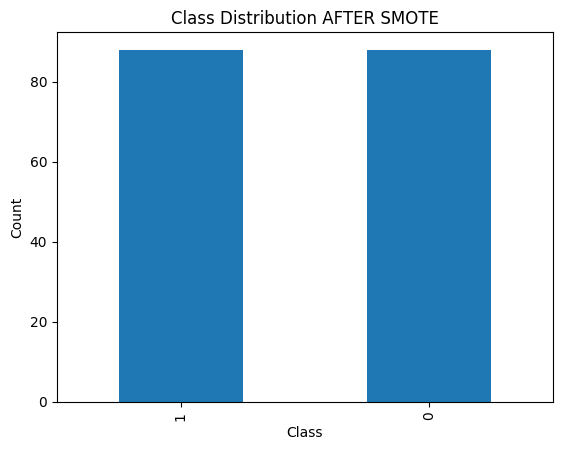

In [14]:
plt.figure()
pd.Series(y_train_sm).value_counts().plot(kind='bar')
plt.title("Class Distribution AFTER SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [15]:
model_after = RandomForestClassifier(n_estimators=100, random_state=42)
model_after.fit(X_train_sm, y_train_sm)

<IPython.core.display.Javascript object>

RandomForestClassifier(random_state=42)

In [16]:
y_pred_after = model_after.predict(X_test)

print(classification_report(y_test, y_pred_after))

              precision    recall  f1-score   support

           0       0.91      0.91      0.91        22
           1       0.00      0.00      0.00         2

    accuracy                           0.83        24
   macro avg       0.45      0.45      0.45        24
weighted avg       0.83      0.83      0.83        24



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

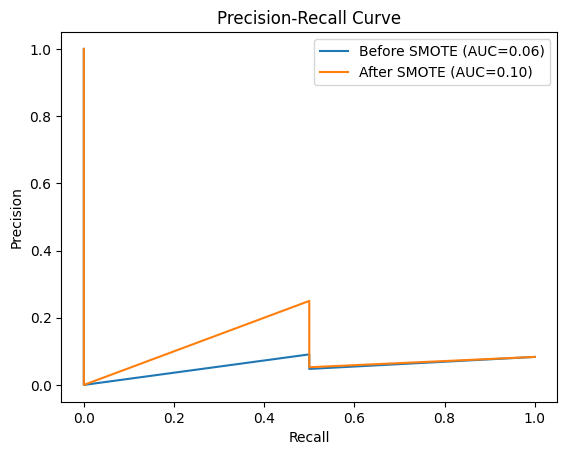

In [17]:

y_prob_before = model_before.predict_proba(X_test)[:, 1]
y_prob_after = model_after.predict_proba(X_test)[:, 1]

precision_b, recall_b, _ = precision_recall_curve(y_test, y_prob_before)
precision_a, recall_a, _ = precision_recall_curve(y_test, y_prob_after)

pr_auc_before = auc(recall_b, precision_b)
pr_auc_after = auc(recall_a, precision_a)

plt.figure()
plt.plot(recall_b, precision_b, label=f"Before SMOTE (AUC={pr_auc_before:.2f})")
plt.plot(recall_a, precision_a, label=f"After SMOTE (AUC={pr_auc_after:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()